<a href="https://colab.research.google.com/github/ensarakbas77/Traffic-Sign-Recognition/blob/main/TrafficSignRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ensarakba","key":"da93bf9e124ca6a3d842ccc01fb768ac"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0


In [ ]:
!unzip -q gtsrb-german-traffic-sign.zip

In [ ]:
!ls

gtsrb-german-traffic-sign.zip  meta  Meta.csv	  test	Test.csv  Train
kaggle.json		       Meta  sample_data  Test	train	  Train.csv


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.metrics import accuracy_score

In [ ]:
train_path = 'Train'
num_classes = len(os.listdir(train_path))
print(f"Toplam sınıf sayısı: {num_classes}")

total_images = 0

for class_dir in os.listdir(train_path):
    class_path = os.path.join(train_path, class_dir)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"Sınıf {class_dir}: {num_images} görsel")
        total_images += num_images

print(f"Toplam eğitim verisi sayısı: {total_images}")

Toplam sınıf sayısı: 43
Sınıf 2: 2250 görsel
Sınıf 27: 240 görsel
Sınıf 17: 1110 görsel
Sınıf 4: 1980 görsel
Sınıf 33: 689 görsel
Sınıf 38: 2070 görsel
Sınıf 36: 390 görsel
Sınıf 26: 600 görsel
Sınıf 10: 2010 görsel
Sınıf 0: 210 görsel
Sınıf 20: 360 görsel
Sınıf 39: 300 görsel
Sınıf 21: 330 görsel
Sınıf 40: 360 görsel
Sınıf 6: 420 görsel
Sınıf 12: 2100 görsel
Sınıf 13: 2160 görsel
Sınıf 3: 1410 görsel
Sınıf 1: 2220 görsel
Sınıf 22: 390 görsel
Sınıf 41: 240 görsel
Sınıf 24: 270 görsel
Sınıf 35: 1200 görsel
Sınıf 11: 1320 görsel
Sınıf 25: 1500 görsel
Sınıf 18: 1200 görsel
Sınıf 30: 450 görsel
Sınıf 14: 780 görsel
Sınıf 19: 210 görsel
Sınıf 16: 420 görsel
Sınıf 5: 1860 görsel
Sınıf 7: 1440 görsel
Sınıf 15: 630 görsel
Sınıf 31: 780 görsel
Sınıf 23: 510 görsel
Sınıf 8: 1410 görsel
Sınıf 42: 240 görsel
Sınıf 29: 270 görsel
Sınıf 9: 1470 görsel
Sınıf 34: 420 görsel
Sınıf 32: 240 görsel
Sınıf 28: 540 görsel
Sınıf 37: 210 görsel
Toplam eğitim verisi sayısı: 39209


In [ ]:
img_size = 30

# Veri ve etiketler
X = []  # Görseller
y = []  # Etiketler

train_path = 'Train'
for class_label in os.listdir(train_path):
    class_dir = os.path.join(train_path, class_label)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (img_size, img_size))
                X.append(img)
                y.append(int(class_label))
            except:
                print(f"Hatalı görsel atlandı: {img_path}")

X = np.array(X)
y = np.array(y)

print(f"Toplam örnek sayısı: {len(X)}")
print(f"Giriş şekli: {X.shape}")
print(f"Etiket şekli: {y.shape}")

Toplam örnek sayısı: 39209
Giriş şekli: (39209, 30, 30, 3)
Etiket şekli: (39209,)


In [ ]:
# Eğitim/Test Kümesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Validation Kümesi
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print(f"Train verisi: {X_train.shape}, {y_train.shape}")
print(f"Validation verisi: {X_val.shape}, {y_val.shape}")
print(f"Test verisi: {X_test.shape}, {y_test.shape}")

y_train = to_categorical(y_train, 43)
y_val = to_categorical(y_val, 43)
y_test = to_categorical(y_test, 43)

Train verisi: (28230, 30, 30, 3), (28230,)
Validation verisi: (3137, 30, 30, 3), (3137,)
Test verisi: (7842, 30, 30, 3), (7842,)


In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(30, 30, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(43, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,627 (920.42 KB)

 Trainable params: 235,627 (920.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2733 - loss: 5.2346 - val_accuracy: 0.7909 - val_loss: 0.7592
Epoch 2/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7991 - loss: 0.7186 - val_accuracy: 0.9299 - val_loss: 0.2542
Epoch 3/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9001 - loss: 0.3521 - val_accuracy: 0.9621 - val_loss: 0.1474
Epoch 4/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9257 - loss: 0.2641 - val_accuracy: 0.9643 - val_loss: 0.1307
Epoch 5/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9526 - loss: 0.1688 - val_accuracy: 0.9688 - val_loss: 0.1331
Epoch 6/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9532 - loss: 0.1605 - val_accuracy: 0.9643 - val_loss: 0.1320
Epoch 7/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9666 - loss: 0.1214 - val_accuracy: 0.9713 - val_loss: 0.1280
Epoch 8/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9633 - loss: 0.1301 - val_accuracy: 

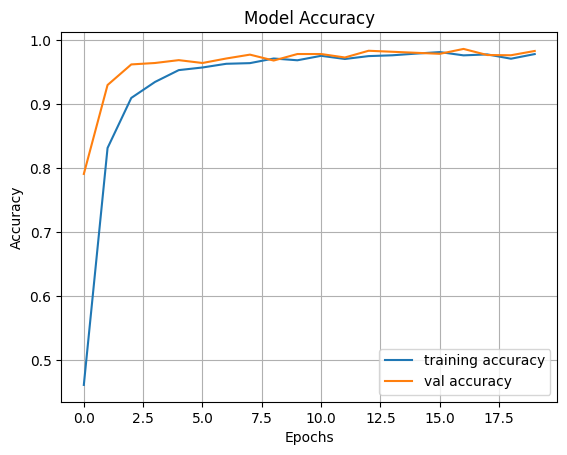

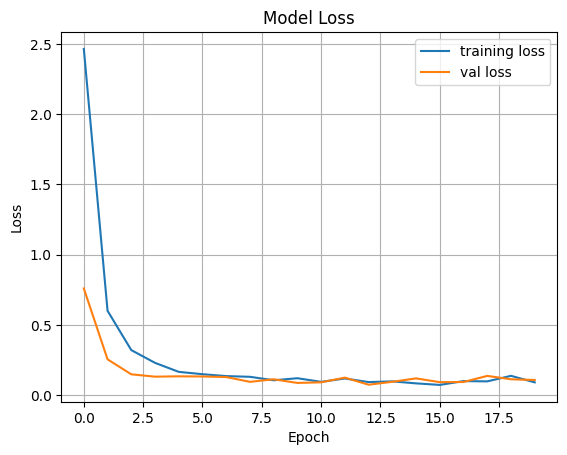

In [ ]:
# Accuracy chart
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss chart
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=-1)

true_classes = np.argmax(y_test, axis=-1)

test_accuracy = accuracy_score(true_classes, predicted_classes)

print(f"Test Doğruluğu: {test_accuracy:.4f}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test Doğruluğu: 0.9844


In [ ]:
model.save("traffic.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


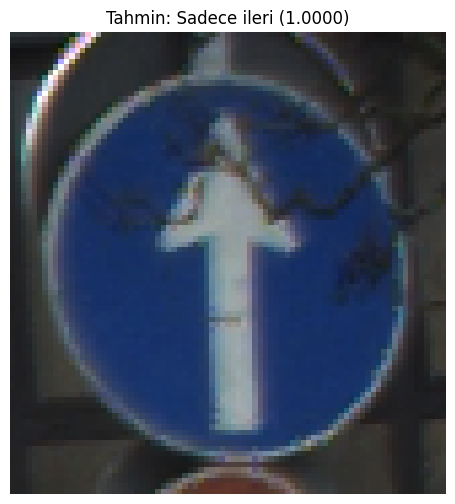


Tahmin edilen sınıf: 35, Olasılık: 1.0000


In [ ]:
def traffic_sign_inference(image_path, model, img_size=30):
    class_labels = {
    0:'Hız sınırı (20km/s)',
    1:'Hız bölgesi (30km/h)',
    2:'Hız bölgesi (50km/h)',
    3:'Hız sınırı (60km/saat)',
    4:'Hız bölgesi (70km/saat)',
    5:'Hız bölgesi (80km/saat)',
    6:'Hız bölgesinin sonu (80km/h)',
    7:'Hız bölgesi (100km/h)',
    8:'Hız bölgesi (120km/h)',
    9:'Geçmek yok',
    10:'3,5 tonun üzerinde araç geçemez',
    11:'Kavşakta geçiş hakkı',
    12:'Öncelikli yol',
    13:'Verim',
    14:'Dur',
    15:'Araç yok',
    16:'3,5 tonluk araçlar yasaktır',
    17:'Giriş yasaktır',
    18:'Genel uyarı',
    19:'Sola tehlikeli viraj',
    20:'Sağa tehlikeli viraj',
    21:'Çift viraj',
    22:'Engebeli yol',
    23:'Kaygan yol',
    24:'Yol sağda daralıyor',
    25:'Yol çalışması',
    26:'Trafik sinyalleri',
    27:'Yayalar',
    28:'Çocukların geçişi',
    29:'Bisikletlerin geçişi',
    30:'Buz/kar konusunda dikkatli olun',
    31:'Vahşi hayvanların geçişi',
    32:'Hız sonu + geçiş sınırları',
    33:'İleride sağa dön',
    34:'İleride sola dön',
    35:'Sadece ileri',
    36:'Düz veya sağa git',
    37:'Düz veya sola git',
    38:'Sağda kal',
    39:'Solda kal',
    40:'Döner kavşak zorunlu',
    41:'Geçiş yasağının sonu',
    42:'Geçiş yasağının sonu > 3,5 tonluk araç'
    }

    try:
        img = cv2.imread(image_path)
        if img is None:
            print("Görsel yüklenemedi!")
            return

        img_resized = cv2.resize(img, (img_size, img_size))

        img_array = np.expand_dims(img_resized, axis=0)

        predictions = model.predict(img_array)
        predicted_class = np.argmax(predictions, axis=1)[0]
        probability = np.max(predictions)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"Tahmin: {class_labels[predicted_class]} ({probability:.4f})")
        plt.show()

        return predicted_class, probability, class_labels[predicted_class]

    except Exception as e:
        print(f"Hata oluştu: {str(e)}")
        return None, None, None

# Kaydettiğimiz "traffic.keras" Modelini Yükleyelim...
try:
    model_path = "traffic.keras"
    model = keras.models.load_model(model_path)


    test_images = ['Test/00009.png']
    for path in test_images:
        if os.path.exists(path):
            result = traffic_sign_inference(path, model)
            if result[0] is not None:
                print(f"\nTahmin edilen sınıf: {result[0]}, Olasılık: {result[1]:.4f}")
        else:
            print(f"Görsel bulunamadı: {path}")

except Exception as e:
    print(f"Model yüklenirken hata oluştu: {str(e)}")